# Task 1: Data Immersion and Wrangling

## Step 1: Data Access and Familiarization

### 1.1 Load the dataset

In [10]:
import pandas as pd
df = pd.read_csv('OnlineRetail.csv', encoding='ISO-8859-1')
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


### 1.2 Check the structure

In [13]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [17]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


### 1.3 Generate Basic Column Information

In [20]:
data_dict = pd.DataFrame({
    'Column Name': df.columns,
    'Data Type': df.dtypes,
    'Missing Values': df.isnull().sum(),
    'Unique Values': df.nunique()})
data_dict

,Column Name,Data Type,Missing Values,Unique Values
InvoiceNo,InvoiceNo,object,0,25900
StockCode,StockCode,object,0,4070
Description,Description,object,1454,4223
Quantity,Quantity,int64,0,722
InvoiceDate,InvoiceDate,object,0,23260
UnitPrice,UnitPrice,float64,0,1630
CustomerID,CustomerID,float64,135080,4372
Country,Country,object,0,38


### 1.4 Add Descriptions and Business Relevance

In [23]:
descriptions = {
    'InvoiceNo': 'Invoice number of transaction',
    'StockCode': 'Unique product identifier',
    'Description': 'Product name',
    'Quantity': 'Number of items purchased',
    'InvoiceDate': 'Date and time of invoice',
    'UnitPrice': 'Price per unit',
    'CustomerID': 'Unique customer ID',
    'Country': 'Customer country'}

business_use = {
    'InvoiceNo': 'Track sales',
    'StockCode': 'Inventory tracking',
    'Description': 'Product analytics',
    'Quantity': 'Revenue calculation',
    'InvoiceDate': 'Sales trend analysis',
    'UnitPrice': 'Revenue analysis',
    'CustomerID': 'Customer segmentation',
    'Country': 'Market analysis'}

data_dict['Description'] = data_dict['Column Name'].map(descriptions)
data_dict['Business Use'] = data_dict['Column Name'].map(business_use)

data_dict.to_csv('online_retail_data_dictionary.csv', index=False)
data_dict

,Column Name,Data Type,Missing Values,Unique Values,Description,Business Use
InvoiceNo,InvoiceNo,object,0,25900,Invoice number of transaction,Track sales
StockCode,StockCode,object,0,4070,Unique product identifier,Inventory tracking
Description,Description,object,1454,4223,Product name,Product analytics
Quantity,Quantity,int64,0,722,Number of items purchased,Revenue calculation
InvoiceDate,InvoiceDate,object,0,23260,Date and time of invoice,Sales trend analysis
UnitPrice,UnitPrice,float64,0,1630,Price per unit,Revenue analysis
CustomerID,CustomerID,float64,135080,4372,Unique customer ID,Customer segmentation
Country,Country,object,0,38,Customer country,Market analysis


## Step 2: Data Quality Assessment

### 2.1 Check missing values

In [27]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

### 2.2 Check duplicates

In [30]:
df.duplicated().sum()

5268

In [32]:
df = df.drop_duplicates()

### 2.3 Check negative/zero values

In [35]:
df[df['Quantity'] <= 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,12/9/2011 9:57,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,12/9/2011 10:28,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,12/9/2011 11:57,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,12/9/2011 11:58,1.25,17315.0,United Kingdom


In [37]:
df[df['UnitPrice'] <= 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,12/1/2010 14:32,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,12/1/2010 14:34,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
536981,581234,72817,NaN,27,12/8/2011 10:33,0.0,NaN,United Kingdom
538504,581406,46000M,POLYESTER FILLER PAD 45x45cm,240,12/8/2011 13:58,0.0,NaN,United Kingdom
538505,581406,46000S,POLYESTER FILLER PAD 40x40cm,300,12/8/2011 13:58,0.0,NaN,United Kingdom
538554,581408,85175,NaN,20,12/8/2011 14:06,0.0,NaN,United Kingdom


### 2.4 Check date format

In [40]:
df['InvoiceDate'] = df['InvoiceDate'].str.strip()

# Convert to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce', dayfirst=True)

# Drop any rows where conversion failed
df = df.dropna(subset=['InvoiceDate'])

print(df['InvoiceDate'].head())
print(df.info())

0   2010-01-12 08:26:00
1   2010-01-12 08:26:00
2   2010-01-12 08:26:00
3   2010-01-12 08:26:00
4   2010-01-12 08:26:00
Name: InvoiceDate, dtype: datetime64[ns]
<class 'pandas.core.frame.DataFrame'>
Index: 230656 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    230656 non-null  object        
 1   StockCode    230656 non-null  object        
 2   Description  229998 non-null  object        
 3   Quantity     230656 non-null  int64         
 4   InvoiceDate  230656 non-null  datetime64[ns]
 5   UnitPrice    230656 non-null  float64       
 6   CustomerID   170492 non-null  float64       
 7   Country      230656 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 15.8+ MB
None


C:\Users\jinal\AppData\Local\Temp\ipykernel_15664\2380187287.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['InvoiceDate'] = df['InvoiceDate'].str.strip()
C:\Users\jinal\AppData\Local\Temp\ipykernel_15664\2380187287.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce', dayfirst=True)


### 2.5 Check outliers

<Axes: xlabel='Quantity'>

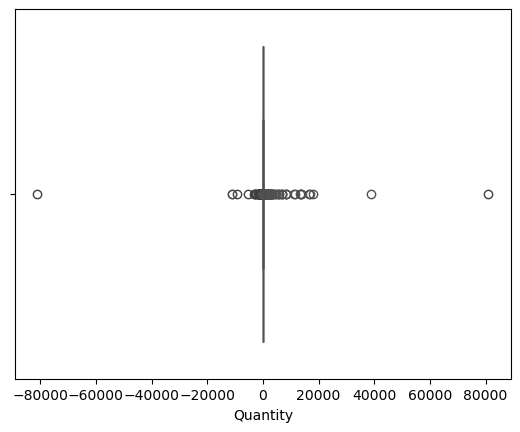

In [43]:
import seaborn as sns
sns.boxplot(x=df['Quantity'])
sns.boxplot(x=df['UnitPrice'])

## Step 3: Data Cleaning & Transformation

### 3.1 Remove missing CustomerID and Description

In [47]:
df = df.dropna(subset=['CustomerID', 'Description'])

### 3.2 Fix text formatting

In [50]:
df['Description'] = df['Description'].str.strip().str.title()

### 3.3 Handle negative quantities (returns)

In [53]:
df_returns = df[df['Quantity'] < 0]  
df = df[df['Quantity'] > 0]         

### 3.4 Feature Engineering

#### Total sales per row:

In [57]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

#### Customer age approximation:

In [60]:
# Example if you had Date of Birth
# df['Customer_Age'] = 2026 - pd.to_datetime(df['DOB']).dt.year

#### Invoice month for trend analysis:

In [63]:
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')

#### Final cleaned dataset:

In [66]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,InvoiceMonth
0,536365,85123A,White Hanging Heart T-Light Holder,6,2010-01-12 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-01
1,536365,71053,White Metal Lantern,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-01
2,536365,84406B,Cream Cupid Hearts Coat Hanger,8,2010-01-12 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-01
3,536365,84029G,Knitted Union Flag Hot Water Bottle,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-01
4,536365,84029E,Red Woolly Hottie White Heart.,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-01
...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,Pack Of 20 Spaceboy Napkins,12,2011-09-12 12:50:00,0.85,12680.0,France,10.20,2011-09
541905,581587,22899,Children'S Apron Dolly Girl,6,2011-09-12 12:50:00,2.10,12680.0,France,12.60,2011-09
541906,581587,23254,Childrens Cutlery Dolly Girl,4,2011-09-12 12:50:00,4.15,12680.0,France,16.60,2011-09
541907,581587,23255,Childrens Cutlery Circus Parade,4,2011-09-12 12:50:00,4.15,12680.0,France,16.60,2011-09


In [68]:
df.to_csv("online_retail_cleaned.csv", index=False)